# Activation energy

In [166]:
from dbm import sqlite3

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

thermal_data = pd.read_csv("thermal_data_2.csv", sep=",", decimal= '.')

reduce_thermal_data = thermal_data.iloc[:, :]

array_thermal_data = reduce_thermal_data.to_numpy()

reduce_thermal_data

,temp,rate
0,21,90.3
1,25,145.0
2,28,199.0
3,32,255.0
4,34,281.0
5,37,301.0
6,40,327.0
7,45,289.0
8,50,238.0


In [167]:
kelvin = 273.15
temp = array_thermal_data[:, 0] + kelvin
velocity = array_thermal_data[:, 1]

print(f"Temp in Kelvin: {temp}")
print(f"Reaction rate: {velocity}")

Temp in Kelvin: [294.15 298.15 301.15 305.15 307.15 310.15 313.15 318.15 323.15]
Reaction rate: [ 90.3 145.  199.  255.  281.  301.  327.  289.  238. ]


We get ln(velocity) and the inverse of the temperture. By plotting these points we can easily find and show the maximum velocity.


In [168]:
ln_velocity = np.log(velocity)
inverse_temp = 1/temp

ln_velocity_slope, ln_velocity_inter = np.polyfit(inverse_temp,ln_velocity, 1)

print(f"inverse Kelvin value: {inverse_temp}")


inverse Kelvin value: [0.00339963 0.00335402 0.0033206  0.00327708 0.00325574 0.00322425
 0.00319336 0.00314317 0.00309454]


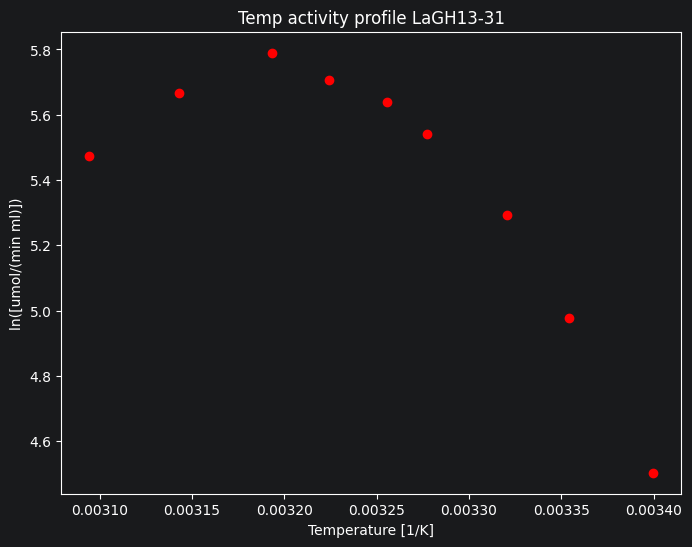

In [169]:
plt.figure(figsize=(8, 6))
plt.scatter(inverse_temp, ln_velocity, color = 'red')
plt.title("Temp activity profile LaGH13-31")
plt.xlabel("Temperature [1/K]")
plt.ylabel("ln([umol/(min ml)])")
plt.grid(False)
plt.show()

Now that we know the maximum velocity and begin to slice the graph until that point, and make the best line of fit. We then obtain the gradient of this line to calculate the activation energy.

In [170]:
line_inv_temp = inverse_temp[:4]
line_ln_velocity = ln_velocity[:4]

slope_vel, inter_vel = np.polyfit(line_inv_temp, line_ln_velocity, 1)

print(f"slope: ", slope_vel)
print(f"intercept: ", inter_vel)

slope:  -8553.94960299182
intercept:  33.63024735175553


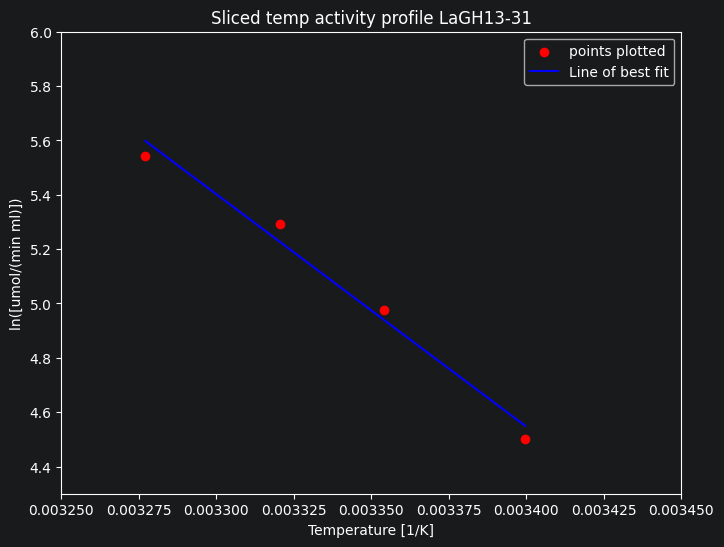

In [171]:
plt.figure(figsize=(8, 6))
plt.scatter(line_inv_temp, line_ln_velocity, color = 'red', label = "points plotted")
plt.plot(line_inv_temp, inter_vel + slope_vel*line_inv_temp, color = 'blue', label = 'Line of best fit')
plt.title("Sliced temp activity profile LaGH13-31")
plt.xlabel("Temperature [1/K]")
plt.ylabel("ln([umol/(min ml)])")
plt.xlim(0.00325, 0.00345)
plt.ylim(4.3, 6)
plt.legend()
plt.grid(False)
plt.show()

In [172]:
gas_constant = 8.3144626181532
L_to_uL = 10**6

#gradient multiplied by the gas constant
activation_energy = gas_constant * (slope_vel / L_to_uL)

print(f"activation energy: ", activation_energy)
print(f"log A: ", inter_vel)

activation energy:  -0.07112149421164189
log A:  33.63024735175553


# volume calculations

In [173]:
final_substrate_conc = 4 # mM
universal_final_vol = 500 # microliters
initial_substrate_conc = 20 #mM
L_to_uL = 10**6 #Liters to microliters

substrate_vol = ((final_substrate_conc * (universal_final_vol)) / initial_substrate_conc)
print(f"substrate volume: ", substrate_vol)
buffer_vol = 250 # microliters
enzyme_vol = 100 # microliters

water_vol = universal_final_vol - (buffer_vol + substrate_vol + enzyme_vol)

print(f"water volume: ", water_vol)

substrate volume:  100.0
water volume:  50.0


# Optimum pH

In [174]:
data_B_C = pd.read_csv("ex4_b.csv", sep = ";", decimal = ',')

reduced_data_B_C = data_B_C.iloc[:, :]

array_pH = reduced_data_B_C.to_numpy()

print(array_pH)

[['A' 0.13 0.22 0.301 0.386 0.474 0.053 0.052 0.052 0.052 0.039 0.04
  0.039 405]
 ['B' 0.123 0.265 0.391 0.547 0.616 0.053 0.053 0.052 0.053 0.052 0.052
  0.052 405]
 ['C' 0.124 0.286 0.457 0.664 0.724 0.052 0.052 0.053 0.053 0.052 0.053
  0.052 405]
 ['D' 0.129 0.299 0.469 0.608 0.776 0.053 0.053 0.053 0.053 0.053 0.053
  0.054 405]
 ['E' 0.121 0.274 0.442 0.592 0.748 0.057 0.053 0.055 0.053 0.053 0.053
  0.053 405]
 ['F' 0.116 0.242 0.367 0.473 0.613 0.053 0.053 0.054 0.053 0.053 0.053
  0.055 405]
 ['G' 0.053 0.053 0.053 0.053 0.053 0.054 0.053 0.053 0.054 0.054 0.054
  0.053 405]
 ['H' 0.051 0.053 0.053 0.053 0.052 0.054 0.054 0.052 0.051 0.054 0.054
  0.053 405]]


In [175]:
blank_mean = np.mean(array_pH[0, 9:13])

absorbance_no_blank = array_pH[:6, 1:6] - blank_mean

print(absorbance_no_blank)

[[0.0875 0.1775 0.2585 0.3435 0.4315]
 [0.08049999999999999 0.2225 0.34850000000000003 0.5045000000000001
  0.5735]
 [0.08149999999999999 0.24349999999999997 0.41450000000000004 0.6215
  0.6815]
 [0.0865 0.2565 0.4265 0.5655 0.7335]
 [0.07849999999999999 0.2315 0.3995 0.5495 0.7055]
 [0.07350000000000001 0.19949999999999998 0.3245 0.4305 0.5705]]


In [176]:
pNP_slope = 0.013400526315789474

pNP_inter = 0.011564912280701573

concentration_pNP_pH = (absorbance_no_blank - pNP_inter) / pNP_slope

print(concentration_pNP_pH)

[[5.666575023238169 12.382729141301088 18.427267847557715
  24.77030229239492 31.337208541167552]
 [5.144207480722163 15.740806200332548 25.14342196562064
  36.78475577026303 41.93380726077794]
 [5.2188314153673065 17.30790882788056 30.068601652200115
  45.51575612374483 49.993192202453436]
 [5.591951088593024 18.27801997826743 30.964088867941832
  41.336815783616785 53.87363680400091]
 [4.9949596114318755 16.41242161213884 28.94924263252296
  40.14283282929449 51.784166633936884]
 [4.6218399382061595 14.024455703494244 23.35244753413719
  31.262584606522406 41.70993545684251]]


In [177]:
universal_time = np.array([0.5, 3.5, 6.5, 9.5, 12.5])

#Array with pH pNP concentration
pH_A = concentration_pNP_pH[0, :].astype(float) # pH 4.5
pH_B = concentration_pNP_pH[1, :].astype(float) # pH 5
pH_C = concentration_pNP_pH [2, :].astype(float) # pH 5.5
pH_D = concentration_pNP_pH[3, :].astype(float) # pH 6
pH_E = concentration_pNP_pH[4, :].astype(float) # pH 6.5
pH_F = concentration_pNP_pH[5, :].astype(float) # pH 7

In [178]:
a_slope, a_inter = np.polyfit(universal_time, pH_A, 1)
b_slope, b_inter = np.polyfit(universal_time, pH_B, 1)
c_slope, c_inter = np.polyfit(universal_time, pH_C, 1)
d_slope, d_inter = np.polyfit(universal_time, pH_D, 1)
e_slope, e_inter = np.polyfit(universal_time, pH_E, 1)
f_slope, f_inter = np.polyfit(universal_time, pH_F, 1)

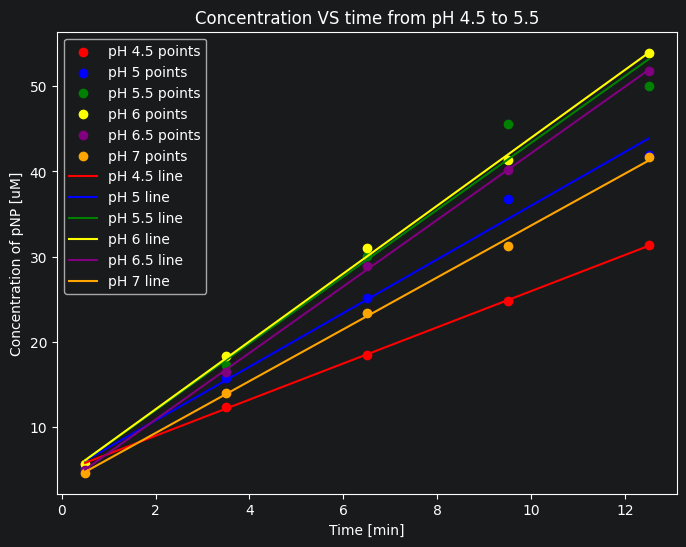

In [179]:
plt.figure(figsize=(8, 6))
plt.scatter(universal_time, pH_A, color ='red', label ="pH 4.5 points")
plt.scatter(universal_time, pH_B, color ='blue', label ="pH 5 points")
plt.scatter(universal_time, pH_C, color ='green', label ="pH 5.5 points")
plt.scatter(universal_time, pH_D, color ='yellow', label ="pH 6 points")
plt.scatter(universal_time, pH_E, color ='purple', label ="pH 6.5 points")
plt.scatter(universal_time, pH_F, color ='orange', label ="pH 7 points")

#Line of best fit
plt.plot(universal_time, a_inter + a_slope * universal_time, color ='red', label ="pH 4.5 line")
plt.plot(universal_time, b_inter + b_slope * universal_time, color ='blue', label ="pH 5 line")
plt.plot(universal_time, c_inter + c_slope * universal_time, color ='green', label ="pH 5.5 line")
plt.plot(universal_time, d_inter + d_slope * universal_time, color ='yellow', label ="pH 6 line")
plt.plot(universal_time, e_inter + e_slope * universal_time, color ='purple', label ="pH 6.5 line")
plt.plot(universal_time, f_inter + f_slope * universal_time, color ='orange', label ="pH 7 line")

plt.title("Concentration VS time from pH 4.5 to 5.5")
plt.ylabel("Concentration of pNP [uM]")
plt.xlabel("Time [min]")
plt.legend()
plt.grid(False)
plt.show()

In [180]:
pH_A_gradient, pH_A_inter = np.polyfit(universal_time[:3], pH_A[:3], 1)
pH_B_gradient, pH_B_inter = np.polyfit(universal_time[:3], pH_B[:3], 1)
pH_C_gradient, pH_C_inter = np.polyfit(universal_time[:3], pH_C[:3], 1)
pH_D_gradient, pH_D_inter = np.polyfit(universal_time[:3], pH_D[:3], 1)
pH_E_gradient, pH_E_inter = np.polyfit(universal_time[:3], pH_E[:3], 1)
pH_F_gradient, pH_F_inter = np.polyfit(universal_time[:3], pH_F[:3], 1)

pH_rate = np.array([pH_A_gradient, pH_B_gradient, pH_C_gradient, pH_D_gradient, pH_E_gradient, pH_F_gradient])

pH_values = np.array([4.5, 5.0, 5.5, 6.0, 6.5, 7.0])

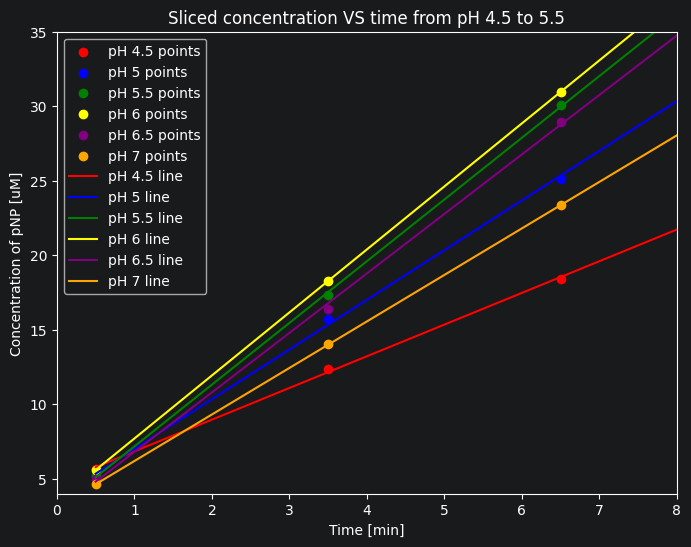

In [181]:
plt.figure(figsize=(8, 6))
plt.scatter(universal_time[:3], pH_A[:3], color ='red', label ="pH 4.5 points")
plt.scatter(universal_time[:3], pH_B[:3], color ='blue', label ="pH 5 points")
plt.scatter(universal_time[:3], pH_C[:3], color ='green', label ="pH 5.5 points")
plt.scatter(universal_time[:3], pH_D[:3], color ='yellow', label ="pH 6 points")
plt.scatter(universal_time[:3], pH_E[:3], color ='purple', label ="pH 6.5 points")
plt.scatter(universal_time[:3], pH_F[:3], color ='orange', label ="pH 7 points")

#Line of best fit
plt.plot(universal_time, pH_A_inter + pH_A_gradient * universal_time, color ='red', label ="pH 4.5 line")
plt.plot(universal_time, pH_B_inter + pH_B_gradient * universal_time, color ='blue', label ="pH 5 line")
plt.plot(universal_time, pH_C_inter + pH_C_gradient * universal_time, color ='green', label ="pH 5.5 line")
plt.plot(universal_time, pH_D_inter + pH_D_gradient * universal_time, color ='yellow', label ="pH 6 line")
plt.plot(universal_time, pH_E_inter + pH_E_gradient * universal_time, color ='purple', label ="pH 6.5 line")
plt.plot(universal_time, pH_F_inter + pH_F_gradient * universal_time, color ='orange', label ="pH 7 line")

plt.title("Sliced concentration VS time from pH 4.5 to 5.5")
plt.ylabel("Concentration of pNP [uM]")
plt.xlabel("Time [min]")
plt.xlim(0, 8)
plt.ylim(4, 35)
plt.legend()
plt.grid(False)
plt.show()

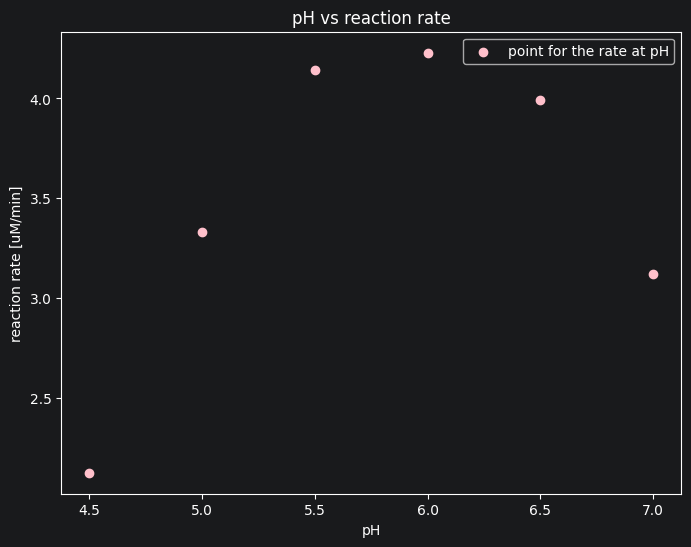

In [182]:
plt.figure(figsize=(8, 6))
plt.scatter(pH_values, pH_rate, color = 'pink', label = "point for the rate at pH")
plt.title("pH vs reaction rate")
plt.xlabel("pH")
plt.ylabel("reaction rate [uM/min]")
plt.legend()
plt.grid(False)
plt.show()

# Reaction rate, time and substrate concentration

In [183]:
final_volume = 500

Assay_vol = 100
enzyme_mix = 100

final_L_conc = 0.4
final_H_conc = 5

#initial volume of the substrate
initial_L_vol = (final_L_conc * final_volume) / initial_substrate_conc

initial_H_vol = (final_H_conc * final_volume) / initial_substrate_conc

print(f"L initial volume: ", initial_L_vol)
print(f"H initial volume: ", initial_H_vol)

#volume of water
volume_water_L = final_volume - initial_L_vol - Assay_vol - enzyme_vol

volume_water_H = final_volume - initial_H_vol - Assay_vol - enzyme_vol

print(f"L volume of water: ", volume_water_L)
print(f"H volume of water: ", volume_water_H)


L initial volume:  10.0
H initial volume:  125.0
L volume of water:  290.0
H volume of water:  175.0


In [184]:
data_C = pd.read_csv("ex4_c.csv", sep = ";", decimal = ',')

reduced_data_C = data_C.iloc[6:, 1:9]

array_HL = reduced_data_C.to_numpy()


In [185]:
H_and_L_noBlank = array_HL - blank_mean

concentration_pNP_HL = (H_and_L_noBlank - pNP_inter) / pNP_slope

In [186]:
high_conc = concentration_pNP_HL[1, :].astype(float)

low_conc = concentration_pNP_HL[0, :].astype(float)
print(f"concentrations for pNP in H are {high_conc} uM \n Concentrations for pNP in L are {low_conc} uM")

concentrations for pNP in H are [ 10.74100258  22.15846458  33.50130265  44.69489284  56.03773091
  70.81326997  86.26042444 113.64740845] uM 
 Concentrations for pNP in L are [ 1.33838681  4.547216    7.08442978  9.62164356 12.68122488 16.03930194
 19.32275506 32.23269576] uM


In [187]:
time_C = np.array([0.5, 3.5, 6.5, 9.5, 12.5, 16.5, 20.5, 30.5])
H_slope, H_inter = np.polyfit(time_C, high_conc, 1)
L_slope, L_inter = np.polyfit(time_C, low_conc, 1)
print(H_slope)
print(L_slope)

3.4949245118821977
0.9949119832659644


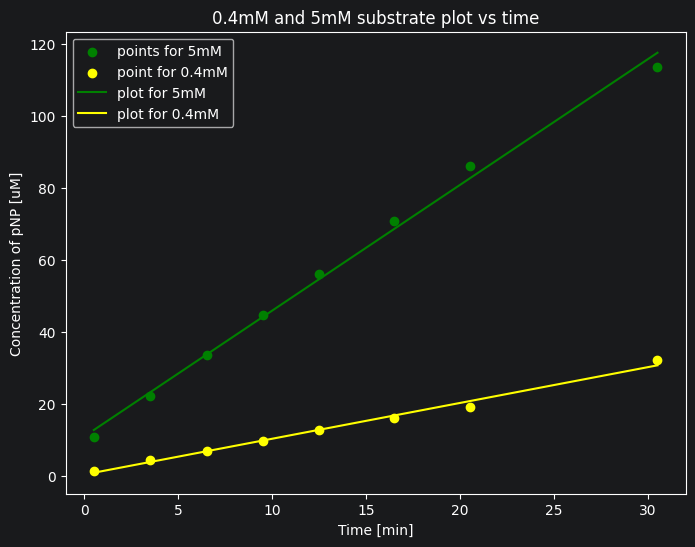

In [188]:
plt.figure(figsize=(8, 6))
plt.scatter(time_C, high_conc, color ='green', label ="points for 5mM")
plt.scatter(time_C, low_conc, color ='yellow', label ="point for 0.4mM")
plt.plot(time_C, H_inter + H_slope * time_C, color = 'green', label = "plot for 5mM")
plt.plot(time_C, L_inter + L_slope * time_C, color = 'yellow', label = "plot for 0.4mM")
plt.title("0.4mM and 5mM substrate plot vs time")
plt.xlabel("Time [min]")
plt.ylabel("Concentration of pNP [uM]")
plt.legend()
plt.grid(False)
plt.show()

In [189]:
sliced_time_HL = time_C[:4]

sliced_pNP_L = low_conc[:4]

sliced_pNP_H = high_conc[:4]

sliced_H_slope, sliced_H_inter = np.polyfit(sliced_time_HL, sliced_pNP_H, 1)

sliced_L_slope, sliced_H_inter = np.polyfit(sliced_time_HL, sliced_pNP_L, 1)

print(f"The slope of L is {sliced_L_slope} mM/min, and the slope for H is {sliced_H_slope} mM/min")

The slope of L is 0.9128994671589223 mM/min, and the slope for H is 3.7734836285560913 mM/min


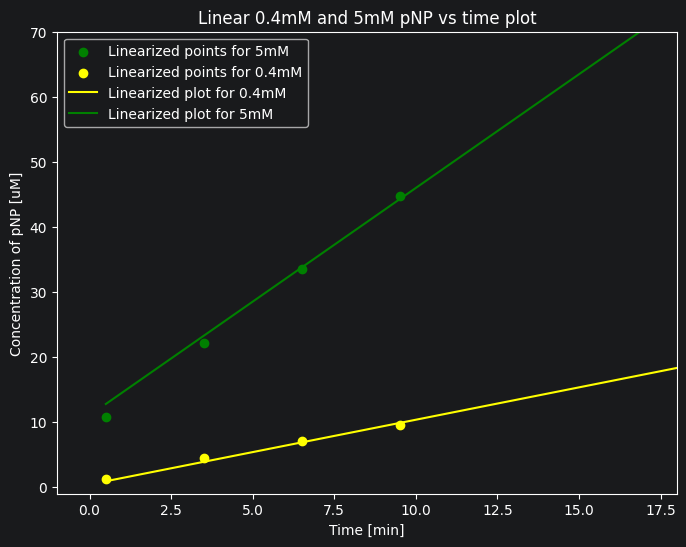

In [190]:
plt.figure(figsize=(8, 6))
plt.scatter(sliced_time_HL, sliced_pNP_H, color = 'green', label = "Linearized points for 5mM")
plt.scatter(sliced_time_HL, sliced_pNP_L, color = 'yellow', label = "Linearized points for 0.4mM")
plt.plot(time_C, L_inter + L_slope * time_C, color = 'yellow', label = "Linearized plot for 0.4mM")
plt.plot(time_C, H_inter + H_slope * time_C, color = 'green', label = "Linearized plot for 5mM")
plt.title("Linear 0.4mM and 5mM pNP vs time plot")
plt.xlabel("Time [min]")
plt.ylabel("Concentration of pNP [uM]")
plt.xlim(-1, 18)
plt.ylim(-1, 70)
plt.legend()
plt.grid(False)
plt.show()

# D1 data

In [191]:
data_completed = pd.read_csv('ex4_all_data.csv', sep = ";", decimal = ',')

reduced_data_d1 = data_completed.iloc[:, 1:6]

array_d1 = reduced_data_d1.to_numpy()

print(array_d1)

[[0.077 0.128 0.174 0.228 0.274]
 [0.102 0.177 0.255 0.337 0.403]
 [0.118 0.228 0.318 0.432 0.497]
 [0.159 0.299 0.44  0.448 0.698]
 [0.248 0.391 0.576 0.704 0.878]
 [0.312 0.501 0.655 0.82  0.898]
 [0.052 0.052 0.053 0.052 0.056]
 [0.041 0.043 0.042 0.053 0.055]]


In [192]:
substrate_conc = np.array([0.6, 1, 2, 4, 8, 12])

In [193]:
abs_mean_blank = np.mean(array_d1[7, 1:3])
abs_s_noblank = array_d1[:6, :] - abs_mean_blank

conc_pNP_noInhibition = (abs_s_noblank - pNP_inter) / pNP_slope


print(abs_mean_blank)

0.042499999999999996


In [194]:
#substrate concentrations in each row
s1_a = conc_pNP_noInhibition[0, :]
s2_a = conc_pNP_noInhibition[1,:]
s3_a = conc_pNP_noInhibition[2, :]
s4_a = conc_pNP_noInhibition[3, :]
s5_a = conc_pNP_noInhibition[4, :]
s6_a = conc_pNP_noInhibition[5, :]


In [195]:
#make sure to slice it
s1_slope, s1_inter = np.polyfit(universal_time[:3], s1_a[:3], 1)
s2_slope, s2_inter = np.polyfit(universal_time[:3], s2_a[:3], 1)
s3_slope, s3_inter = np.polyfit(universal_time[:3], s3_a[:3], 1)
s4_slope, s4_inter = np.polyfit(universal_time[:3], s4_a[:3], 1)
s5_slope, s5_inter = np.polyfit(universal_time[:3], s5_a[:3], 1)
s6_slope, s6_inter = np.polyfit(universal_time[:3], s6_a[:3], 1)

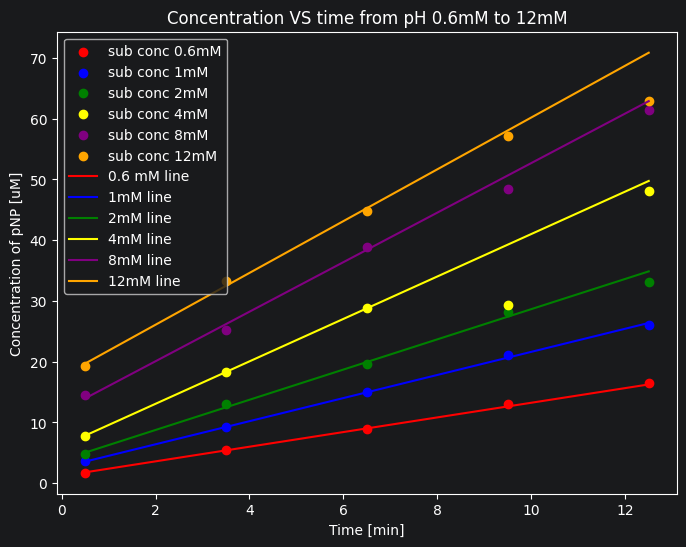

In [196]:
plt.figure(figsize=(8, 6))
plt.scatter(universal_time, s1_a, color ='red', label ="sub conc 0.6mM")
plt.scatter(universal_time, s2_a, color ='blue', label ="sub conc 1mM")
plt.scatter(universal_time, s3_a, color ='green', label ="sub conc 2mM")
plt.scatter(universal_time, s4_a, color ='yellow', label ="sub conc 4mM")
plt.scatter(universal_time, s5_a, color ='purple', label ="sub conc 8mM")
plt.scatter(universal_time, s6_a, color ='orange', label ="sub conc 12mM")

#Line of best fit
plt.plot(universal_time, s1_inter + s1_slope * universal_time, color ='red', label ="0.6 mM line")
plt.plot(universal_time, s2_inter + s2_slope * universal_time, color ='blue', label ="1mM line")
plt.plot(universal_time, s3_inter + s3_slope * universal_time, color ='green', label ="2mM line")
plt.plot(universal_time, s4_inter + s4_slope * universal_time, color ='yellow', label ="4mM line")
plt.plot(universal_time, s5_inter + s5_slope * universal_time, color ='purple', label ="8mM line")
plt.plot(universal_time, s6_inter + s6_slope * universal_time, color ='orange', label ="12mM line")

plt.title("Concentration VS time from pH 0.6mM to 12mM")
plt.ylabel("Concentration of pNP [uM]")
plt.xlabel("Time [min]")
plt.legend()
plt.grid(False)
plt.show()

In [197]:
gradients_without_inhibition= np.array([s1_slope, s2_slope, s3_slope, s4_slope, s5_slope, s6_slope])

print(f"Gradient for each concentration {gradients_without_inhibition}")

Gradient for each concentration [1.20642028 1.90291033 2.48746449 3.49488761 4.07944176 4.2660016 ]


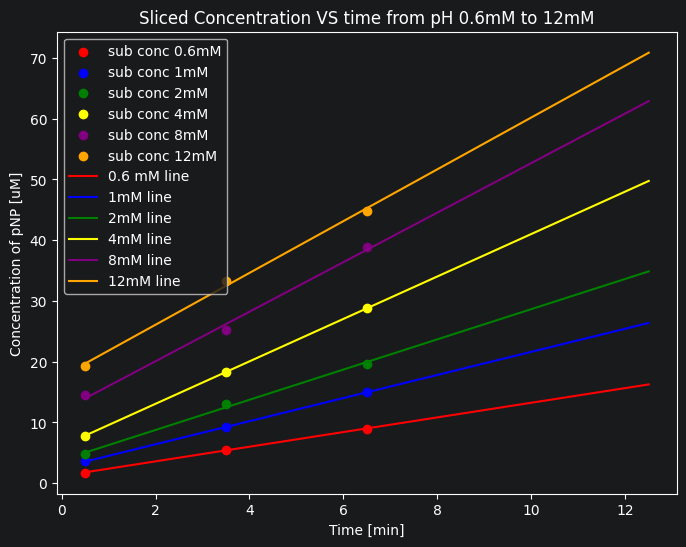

In [198]:
#remember to slice this
plt.figure(figsize=(8, 6))
plt.scatter(universal_time[0:3], s1_a[:3], color ='red', label ="sub conc 0.6mM")
plt.scatter(universal_time[:3], s2_a[:3], color ='blue', label ="sub conc 1mM")
plt.scatter(universal_time[:3], s3_a[:3], color ='green', label ="sub conc 2mM")
plt.scatter(universal_time[:3], s4_a[:3], color ='yellow', label ="sub conc 4mM")
plt.scatter(universal_time[:3], s5_a[:3], color ='purple', label ="sub conc 8mM")
plt.scatter(universal_time[:3], s6_a[:3], color ='orange', label ="sub conc 12mM")


#Line of best fit
plt.plot(universal_time, s1_inter + s1_slope * universal_time, color ='red', label ="0.6 mM line")
plt.plot(universal_time, s2_inter + s2_slope * universal_time, color ='blue', label ="1mM line")
plt.plot(universal_time, s3_inter + s3_slope * universal_time, color ='green', label ="2mM line")
plt.plot(universal_time, s4_inter + s4_slope * universal_time, color ='yellow', label ="4mM line")
plt.plot(universal_time, s5_inter + s5_slope * universal_time, color ='purple', label ="8mM line")
plt.plot(universal_time, s6_inter + s6_slope * universal_time, color ='orange', label ="12mM line")


plt.title("Sliced Concentration VS time from pH 0.6mM to 12mM")
plt.ylabel("Concentration of pNP [uM]")
plt.xlabel("Time [min]")
plt.legend()
plt.grid(False)
plt.show()

In [199]:
inverse_vel = 1 / gradients_without_inhibition

inverse_sub = 1 / substrate_conc

burk_plot_slope, burk_plot_inter = np.polyfit(inverse_sub, inverse_vel, 1)
print(inverse_vel)
print(inverse_sub)

[0.82889853 0.52551084 0.40201579 0.28613223 0.24513158 0.23441154]
[1.66666667 1.         0.5        0.25       0.125      0.08333333]


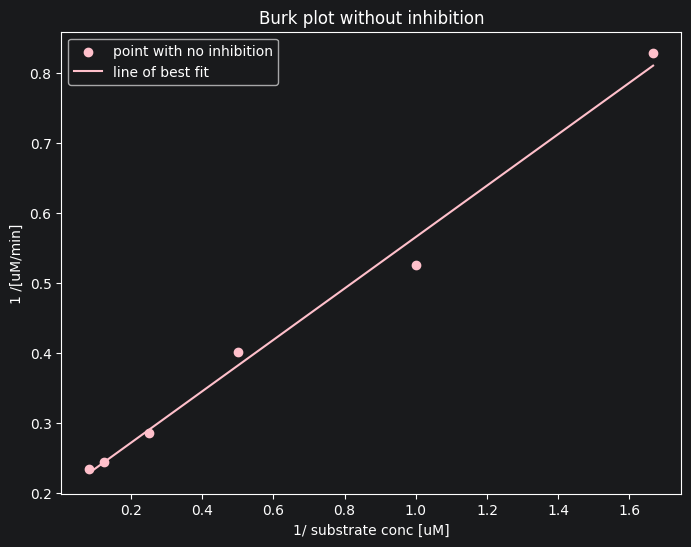

In [200]:
plt.figure(figsize = (8, 6))
plt.scatter(inverse_sub, inverse_vel, color ='pink', label ="point with no inhibition")

plt.plot(inverse_sub, burk_plot_inter + burk_plot_slope * inverse_sub, color = 'pink', label = "line of best fit")

plt.title("Burk plot without inhibition")
plt.ylabel("1 /[uM/min]")
plt.xlabel("1/ substrate conc [uM]")
plt.legend()
plt.grid(False)
plt.show()

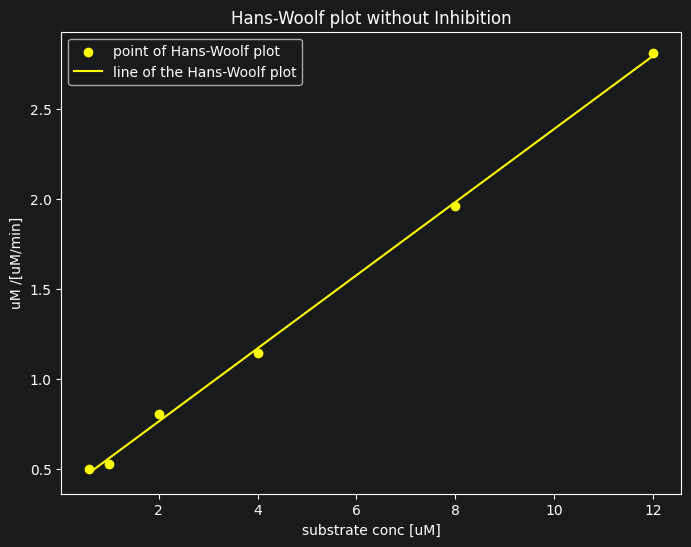

In [201]:
hw_velocity = substrate_conc / gradients_without_inhibition

hw_slope, hw_inter = np.polyfit(substrate_conc, hw_velocity, 1)

plt.figure(figsize=(8, 6))
plt.scatter(substrate_conc, hw_velocity, color = 'yellow', label = "point of Hans-Woolf plot")

plt.plot(substrate_conc, hw_inter + hw_slope * substrate_conc, color = 'yellow', label = "line of the Hans-Woolf plot")

plt.title("Hans-Woolf plot without Inhibition")
plt.ylabel("uM /[uM/min]")
plt.xlabel("substrate conc [uM]")
plt.legend()
plt.grid(False)
plt.show()

In [202]:
vmax_burk = 1 / burk_plot_inter

km_burk = vmax_burk * burk_plot_slope

vmax_hw = 1 / hw_slope

km_hw = vmax_hw * hw_inter

print(f"Burk plot Vmax is {vmax_burk} and Km is {km_burk}. \n Hans-Woolf plot Vmax is {vmax_hw} and Km is {km_hw}")

Burk plot Vmax is 5.037181420903262 and Km is 1.84945595728301. 
 Hans-Woolf plot Vmax is 4.917183712955822 and Km is 1.747593745046595


In [203]:
initial_enzyme_conc = 10 / 10**3 #nm to uM
initial_enzyme_volume = 50

enzyme_conc = initial_enzyme_conc * initial_enzyme_volume / universal_final_vol

k_cat_burk = vmax_burk / enzyme_conc

k_cat_hw = vmax_hw / enzyme_conc

print(f"Kcat for burk is {k_cat_burk}, and Kcat for Hans-Woolf is {k_cat_hw}")

Kcat for burk is 5037.181420903262, and Kcat for Hans-Woolf is 4917.183712955822


# D2 data process

In [204]:
borrowed_data = pd.read_csv("d2_team17.csv", sep=";", decimal= ',')
reduced_data_2d = borrowed_data.iloc[:6, 8:13]

array_d2 = reduced_data_2d.to_numpy()

print(array_d2)

[[0.047 0.065 0.084 0.105 0.126]
 [0.053 0.079 0.109 0.128 0.166]
 [0.06  0.1   0.143 0.185 0.227]
 [0.094 0.19  0.286 0.39  0.484]
 [0.103 0.216 0.335 0.468 0.586]
 [0.123 0.266 0.437 0.584 0.692]]


In [205]:
d2_subtration_blank = array_d2 - abs_mean_blank
conc_pNP_inhibition = (d2_subtration_blank - pNP_inter) / pNP_slope
#concentration affected by inhibition
i1 = conc_pNP_inhibition[0,:]
i2 = conc_pNP_inhibition[1,:]
i3 = conc_pNP_inhibition[2,:]
i4 = conc_pNP_inhibition[3,:]
i5 = conc_pNP_inhibition[4,:]
i6 = conc_pNP_inhibition[5,:]

print(i1)

[-0.52721155  0.81601927  2.23387403  3.80097666  5.36807928]


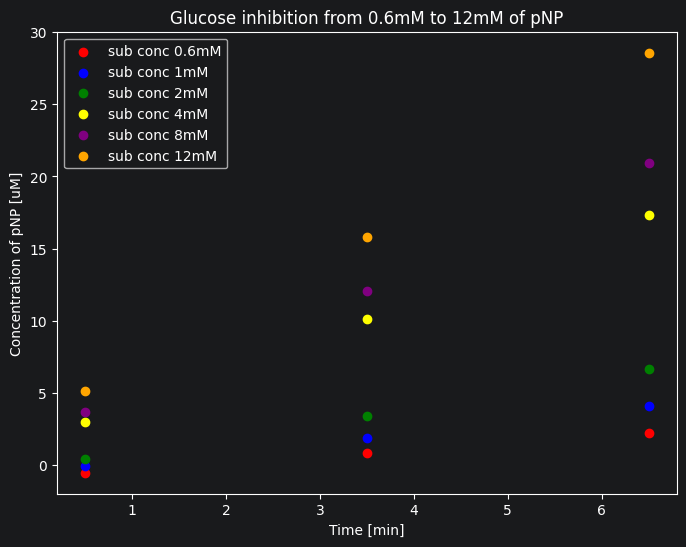

In [206]:

plt.figure(figsize=(8, 6))
plt.scatter(universal_time[:3], i1[:3], color ='red', label ="sub conc 0.6mM")
plt.scatter(universal_time[:3], i2[:3], color ='blue', label ="sub conc 1mM")
plt.scatter(universal_time[:3], i3[:3], color ='green', label ="sub conc 2mM")
plt.scatter(universal_time[:3], i4[:3], color ='yellow', label ="sub conc 4mM")
plt.scatter(universal_time[:3], i5[:3], color ='purple', label ="sub conc 8mM")
plt.scatter(universal_time[:3], i6[:3], color ='orange', label ="sub conc 12mM")

plt.title("Glucose inhibition from 0.6mM to 12mM of pNP")
plt.ylabel("Concentration of pNP [uM]")
plt.xlabel("Time [min]")
plt.legend()
plt.grid(False)
plt.show()

In [207]:
#make sure to slice it
i1_slope, i1_inter = np.polyfit(universal_time[:3], i1[:3], 1)
i2_slope, i2_inter = np.polyfit(universal_time[:3], i2[:3], 1)
i3_slope, i3_inter = np.polyfit(universal_time[:3], i3[:3], 1)
i4_slope, i4_inter = np.polyfit(universal_time[:3], i4[:3], 1)
i5_slope, i5_inter = np.polyfit(universal_time[:3], i5[:3], 1)
i6_slope, i6_inter = np.polyfit(universal_time[:3], i6[:3], 1)

inhibition_gradients = np.array([i1_slope, i2_slope, i3_slope, i4_slope, i5_slope, i6_slope])

print(f"inhibition gradients {inhibition_gradients}")

inhibition gradients [0.46018093 0.69649006 1.03229776 2.38796591 2.88545881 3.90531925]


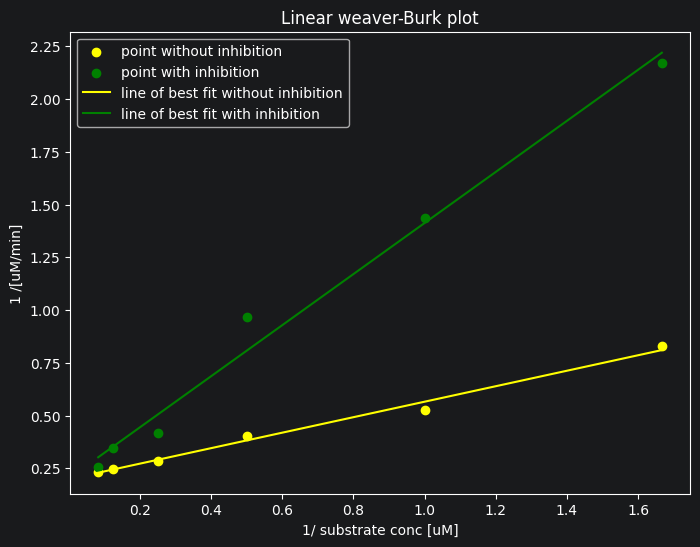

In [208]:
i_burk_vel = 1 / inhibition_gradients

concentration_trial = np.array([0.6, 2, 4, 8, 12])
inhibited_burk_slope, inhibited_burk_inter = np.polyfit(inverse_sub, i_burk_vel, 1)

plt.figure(figsize=(8, 6))
plt.scatter(inverse_sub, inverse_vel, color = 'yellow', label = "point without inhibition")
plt.scatter(inverse_sub, i_burk_vel, color = 'green', label = "point with inhibition")
plt.plot(inverse_sub, burk_plot_inter + burk_plot_slope * inverse_sub, color = 'yellow', label = "line of best fit without inhibition")
plt.plot(inverse_sub, inhibited_burk_inter + inhibited_burk_slope * inverse_sub, color ='green', label ="line of best fit with inhibition")
plt.title("Linear weaver-Burk plot")
plt.ylabel("1 /[uM/min]")
plt.xlabel("1/ substrate conc [uM]")
plt.legend()
plt.grid(False)
plt.show()

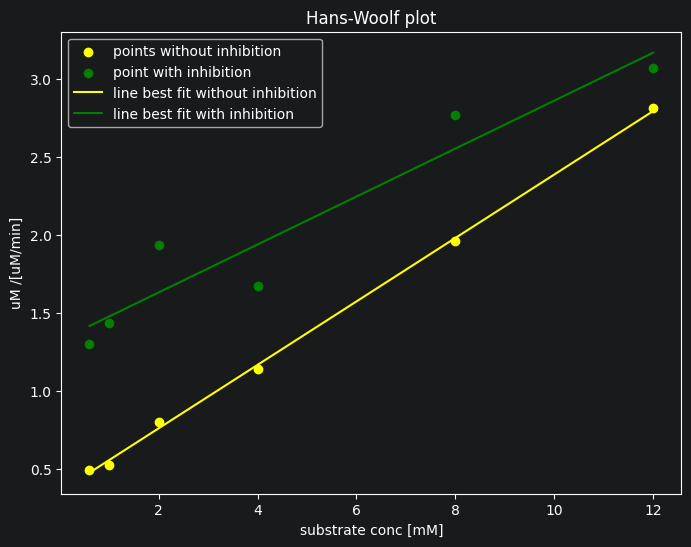

In [209]:
#
inhibited_hw_values = substrate_conc / inhibition_gradients
inhibited_hw_slope, inhibited_hw_inter = np.polyfit(substrate_conc, inhibited_hw_values, 1)

plt.figure(figsize=(8, 6))
plt.scatter(substrate_conc, hw_velocity, color = 'yellow', label = "points without inhibition")
plt.scatter(substrate_conc, inhibited_hw_values, color ='green', label ="point with inhibition")
plt.plot(substrate_conc, hw_inter + hw_slope * substrate_conc, color = 'yellow', label = "line best fit without inhibition")
plt.plot(substrate_conc, inhibited_hw_inter + inhibited_hw_slope * substrate_conc, color ='green', label ="line best fit with inhibition")

plt.title("Hans-Woolf plot")
plt.ylabel("uM /[uM/min]")
plt.xlabel("substrate conc [mM]")
plt.legend()
plt.grid(False)
plt.show()

In [210]:
inhibited_vmax_burk = 1 / inhibited_burk_slope

inhibited_km_burk = inhibited_vmax_burk * inhibited_burk_slope

inhibited_vmax_hw = 1 / inhibited_hw_slope

inhibited_km_hw = inhibited_vmax_hw * inhibited_hw_inter

print(f"inhibition of Burks Vmax is {inhibited_vmax_burk} and Km is {inhibited_km_burk}. \n inhibition Hans-Woolf Vmax is {inhibited_vmax_hw} and Km is {inhibited_km_hw}")

inhibition of Burks Vmax is 0.8257247669415256 and Km is 1.0. 
 inhibition Hans-Woolf Vmax is 6.5064062249411405 and Km is 8.626820930678653


In [211]:
#abstract Ki for inhibition
initial_glucose_conc = 60*10**3 # mM to uM
initial_glucose_volume = 50
glucose_conc = ((initial_glucose_conc * initial_glucose_volume) / universal_final_vol)

ki_hw = glucose_conc / ((inhibited_hw_inter / (vmax_hw / km_hw)) - 1)

ki_burk = glucose_conc / ((inhibited_burk_slope / (vmax_burk / km_burk)) - 1)

print(ki_burk)
print(ki_hw)

-10804.053110161576
-11347.105395955961


In [212]:
#specific Ki for competitive inhibition
specific_ki_hw = glucose_conc / ((inhibited_km_hw / km_hw) - 1)

specific_ki_burk = glucose_conc / ((inhibited_km_burk / km_burk) - 1)

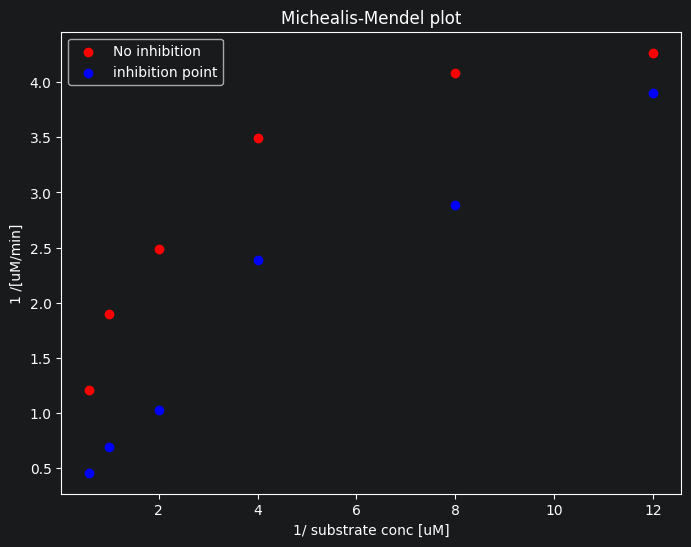

In [213]:
#micheal-mendel
plt.figure(figsize=(8, 6))
plt.scatter(substrate_conc, gradients_without_inhibition, color = 'red', label = "No inhibition")
plt.scatter(substrate_conc, inhibition_gradients, color = 'blue', label = "inhibition point")
plt.title("Michealis-Mendel plot")
plt.ylabel("1 /[uM/min]")
plt.xlabel("1/ substrate conc [uM]")
plt.legend()
plt.grid(False)
plt.show()